In [1]:
import os
os.chdir('../')

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.stattools import acf, pacf

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.stats.diagnostic import acorr_ljungbox

import warnings
warnings.filterwarnings("ignore")

In [27]:
passengers = pd.read_csv('Datasets/air_passengers.csv', 
                 parse_dates = ['date'], date_format='%Y-%m-%d',
                 index_col='date')
passengers = passengers.loc[passengers.name =='Ireland',:]
passengers.columns = [col.lower() for col in passengers.columns]
passengers.head()
passengers = passengers.asfreq('MS')  # Specifies monthly frequency

In [28]:
h = 12
train = passengers.iloc[:-h]
test = passengers.iloc[-h:]
train.head()

,name,total,domestic,international,total_os
date,,,,,
2010-01-01,Ireland,1488.034,30.502,1457.532,1522.530
2010-02-01,Ireland,1548.150,38.198,1509.952,1579.746
2010-03-01,Ireland,1865.279,44.373,1820.906,1898.331
2010-04-01,Ireland,1464.440,25.856,1438.584,1468.642
2010-05-01,Ireland,1968.408,29.101,1939.307,1963.063


ADF Test Statistic: 2.108416174917741
p-value: 0.9987982794721632
----------------------------------------------------------------------------------------------------


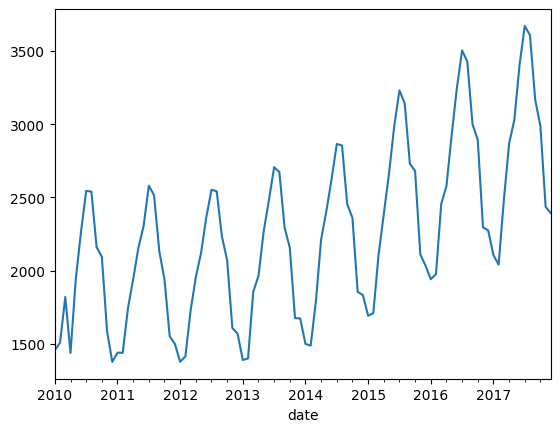

In [29]:
print('ADF Test Statistic:', adfuller(train.international)[0])
print('p-value:', adfuller(train.international)[1])
print('-'*100)
train.international.plot()
plt.show()

Value of lambda to stabilize variance  0.1251694035881738
----------------------------------------------------------------------------------------------------
ADF Test Statistic: 2.4970179762800484
p-value: 0.9990488826509608
----------------------------------------------------------------------------------------------------


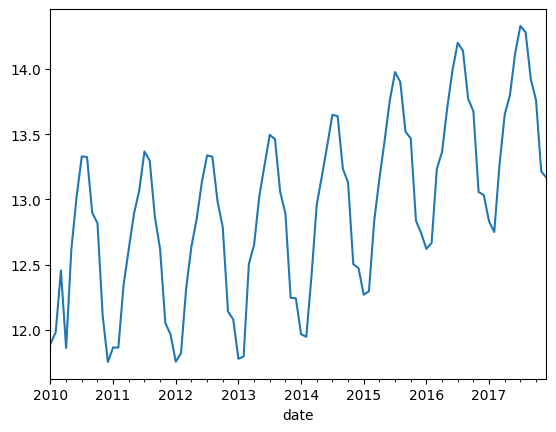

In [30]:
from scipy.stats import boxcox
boxcox_lambda = boxcox(train.international)[1]
print('Value of lambda to stabilize variance ', boxcox_lambda) 
print('-'*100)
international_boxcox = boxcox(train.international)[0]
transformed = pd.DataFrame({'international': train.international, 
                            'international_boxcox': international_boxcox},index = train.index)

print('ADF Test Statistic:', adfuller(transformed.international_boxcox)[0])
print('p-value:', adfuller(transformed.international_boxcox)[1])
print('-'*100)
transformed.international_boxcox.plot()
plt.show()

ADF Test Statistic: -1.9298091565702966
p-value: 0.3181704637817915
----------------------------------------------------------------------------------------------------


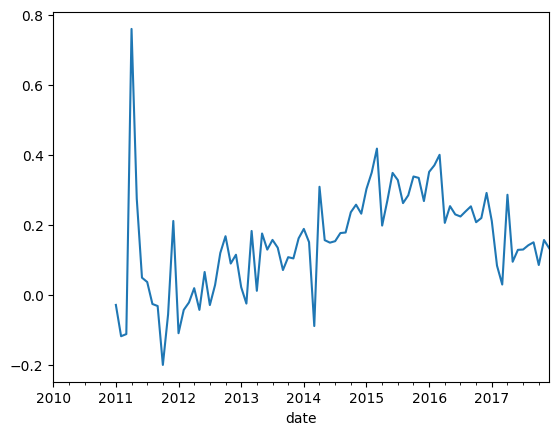

In [31]:
transformed['international_boxcox_sdiff'] = transformed.international_boxcox.diff(12)
print('ADF Test Statistic:', adfuller(transformed.international_boxcox_sdiff.dropna())[0])
print('p-value:', adfuller(transformed.international_boxcox_sdiff.dropna())[1])
print('-'*100)
transformed.international_boxcox_sdiff.plot()
plt.show()

ADF Test Statistic: -11.43896276431314
p-value: 6.246469499030049e-21
----------------------------------------------------------------------------------------------------


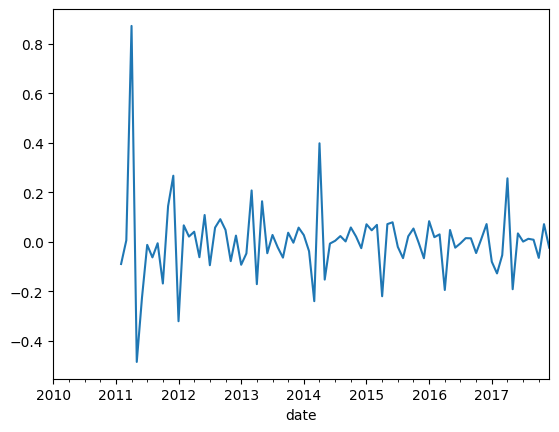

In [32]:
transformed['international_boxcox_sdiff_diff'] = transformed.international_boxcox_sdiff.diff()
print('ADF Test Statistic:', adfuller(transformed.international_boxcox_sdiff_diff.dropna())[0])
print('p-value:', adfuller(transformed.international_boxcox_sdiff_diff.dropna())[1])
print('-'*100)
transformed.international_boxcox_sdiff_diff.plot()
plt.show()

In [33]:
pacf(transformed.international_boxcox_sdiff_diff.dropna(), nlags = 24)

array([ 1.        , -0.38179545, -0.36576069, -0.2428943 , -0.13600033,
       -0.07762104, -0.23882328, -0.22004673,  0.00203172, -0.06315497,
       -0.05722584,  0.08102891, -0.13910396, -0.02415981,  0.03571549,
        0.00952263, -0.12882297, -0.06916871,  0.02862738,  0.00631009,
        0.20110304, -0.05526832, -0.11413771,  0.1375231 , -0.17580455])

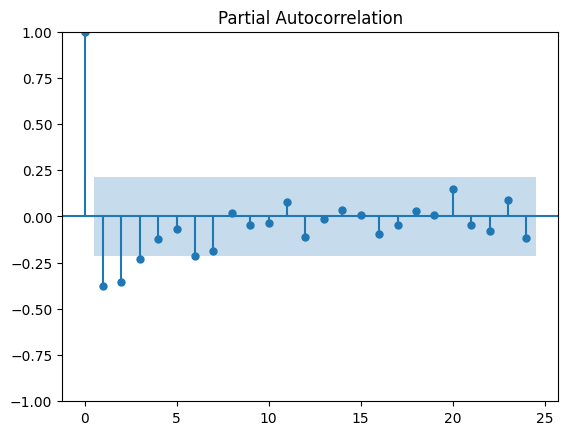

In [34]:
plot_pacf(transformed.international_boxcox_sdiff_diff.dropna(), lags=24)
plt.show()

In [35]:
acf(transformed.international_boxcox_sdiff_diff.dropna(),nlags=24)

array([ 1.        , -0.3771955 , -0.16266051,  0.04513516,  0.04905185,
       -0.00578219, -0.13452645,  0.04738344,  0.15790336, -0.10926659,
       -0.02696399,  0.10150151, -0.12930038,  0.06681487,  0.01061072,
       -0.01262272, -0.05860402,  0.03182974,  0.08314871, -0.04756108,
        0.03160406, -0.09461414,  0.02563588,  0.08899322, -0.16338644])

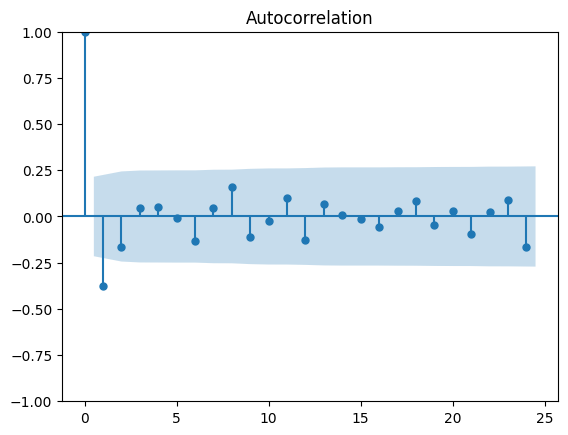

In [36]:
plot_acf(transformed.international_boxcox_sdiff_diff.dropna(),lags=24)
plt.show()

In [38]:
sarima_model  = SARIMAX(train.bc_international, 
                        order = (0,1,2), 
                        seasonal_order=(2,1,2,12))
result = sarima_model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                   bc_international   No. Observations:                   96
Model:             SARIMAX(0, 1, 2)x(2, 1, 2, 12)   Log Likelihood                  60.790
Date:                            Tue, 21 Apr 2026   AIC                           -107.580
Time:                                    11:04:01   BIC                            -90.648
Sample:                                01-01-2010   HQIC                          -100.778
                                     - 12-01-2017                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5121      0.155     -3.312      0.001      -0.815      -0.209
ma.L2         -0.2453      0.127     -1.930      0.054      -0.494       0.004
ar.S.L12      -1.1676      0.266     -4.384      0.000      -1.690      -0.646
ar.S.L24      -0.9448      0.284     -3.327      0.001      -1.501      -0.388
ma.S.L12       1.1406      0.592      1.927      0.054      -0.019       2.300
ma.S.L24       0.7571      0.759      0.998      0.318      -0.730       2.244
sigma2         0.0112      0.005      2.230      0.026       0.001       0.021
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              1151.04
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.10   Skew:                             2.92
Prob(H) (two-sided):                  0.00   Kurtosis:                        20.28
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [39]:
print(acorr_ljungbox(result.resid, lags = 12).iloc[11,:])

lb_stat      18.508798
lb_pvalue     0.101092
Name: 12, dtype: float64


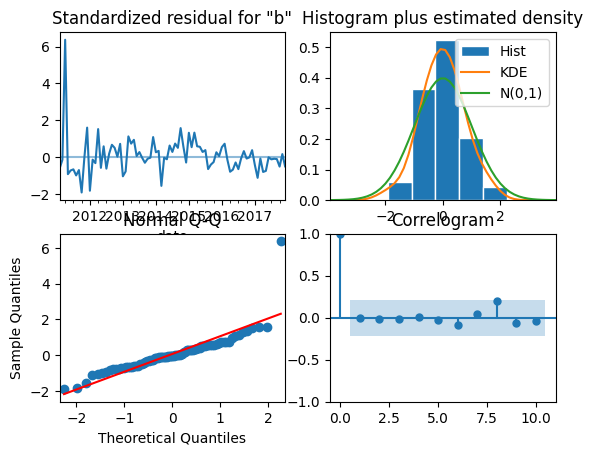

In [40]:
result.plot_diagnostics()
plt.show()

In [41]:
from scipy.special import inv_boxcox
forecasts = test.copy()
forecasts['sarima1'] = inv_boxcox(result.get_prediction(start = test.index[0], end = test.index[-1]).predicted_mean, train_lambda)

In [42]:
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(test.international, forecasts['sarima1'])

83.9694671460516

In [45]:
nvidia = pd.read_csv('Datasets/nvda.csv', 
                parse_dates=['Date'], 
                date_format ='%Y-%m-%d')
nvidia = nvidia.loc[:,['Close_NVDA','Date']]
nvidia.rename(columns= {'Close_NVDA': 'price', 
                                'Date': 'date'}, inplace=True)
nvidia.set_index('date',inplace=True)
nvidia = nvidia.resample('ME').last().asfreq('ME')
#nvidia = nvidia.asfreq('B').ffill()  # Specifies Business Days as frequency
nvidia.head()

,price
date,
2010-01-31,0.352792
2010-02-28,0.371359
2010-03-31,0.398868
2010-04-30,0.360127
2010-05-31,0.301214


In [46]:
h = 24
train = nvidia.iloc[:-h]
train.loc[:,['log_price']] = np.log(train.price)
test = nvidia.iloc[-h:]

ADF Test Statistic: -1.4020385838014402
p-value: 0.5812984065367783
----------------------------------------------------------------------------------------------------


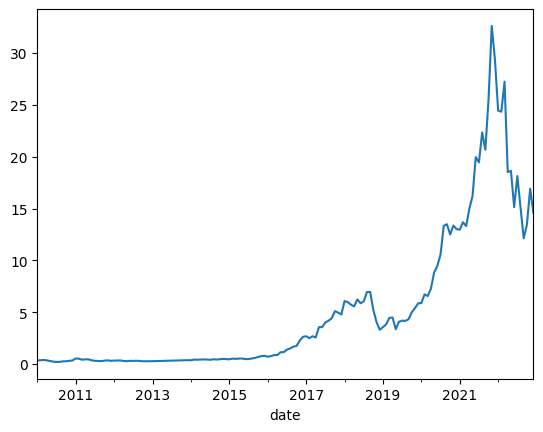

In [47]:
print('ADF Test Statistic:', adfuller(train.price)[0])
print('p-value:', adfuller(train.price)[1])
print('-'*100)
train.price.plot()
plt.show()

ADF Test Statistic: -0.06152279990631547
p-value: 0.9531386920555365
----------------------------------------------------------------------------------------------------


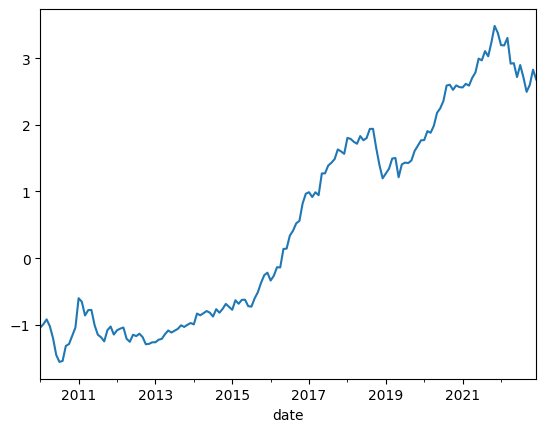

In [48]:
price_log = np.log(train.price)
transformed = pd.DataFrame({'price': train.price, 
                            'price_log': price_log},index = train.index)
print('ADF Test Statistic:', adfuller(transformed.price_log)[0])
print('p-value:', adfuller(transformed.price_log)[1])
print('-'*100)
transformed.price_log.plot()
plt.show()

ADF Test Statistic: -11.24399195184999
p-value: 1.7782471094105432e-20
----------------------------------------------------------------------------------------------------


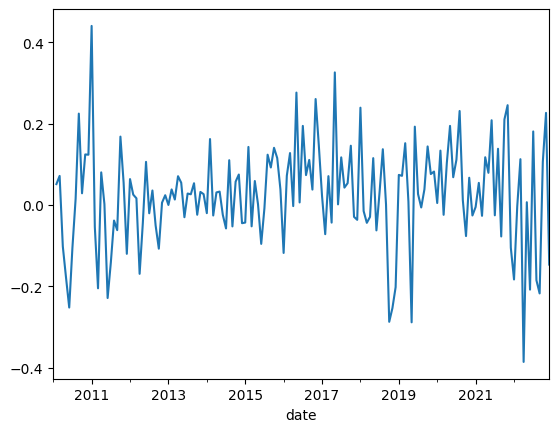

In [49]:
transformed['price_log_diff'] = transformed.price_log.diff()
print('ADF Test Statistic:', adfuller(transformed.price_log_diff.dropna())[0])
print('p-value:', adfuller(transformed.price_log_diff.dropna())[1])
print('-'*100)
transformed.price_log_diff.plot()
plt.show()

[ 1.          0.08537434  0.0032863   0.03820218  0.12327129 -0.08220904
  0.0101646  -0.07897476  0.05217743  0.05178058 -0.01029353 -0.01962378
  0.00807969  0.09390853  0.08170639  0.0056917  -0.16029901 -0.02993799
  0.00868066 -0.05723807  0.05210538 -0.03793468 -0.05981817 -0.06585647
 -0.07947248]
--------------------------------------------------


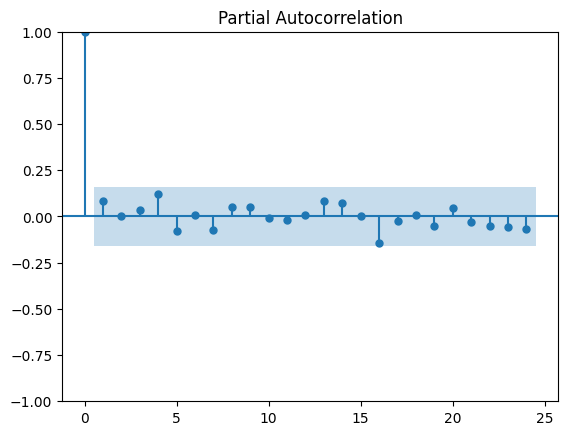

In [50]:
print(pacf(transformed.price_log_diff.dropna(), nlags = 24))
print('-'*50)
plot_pacf(transformed.price_log_diff.dropna(), lags=24)
plt.show()

[ 1.00000000e+00  8.48235405e-02  1.04149817e-02  3.83449123e-02
  1.25453869e-01 -5.71916472e-02  2.37493969e-04 -6.49277704e-02
  4.64484748e-02  3.84596545e-02  1.30872897e-04 -3.33416885e-02
  2.75137252e-02  8.84819254e-02  8.28589555e-02  8.74522329e-03
 -1.22386212e-01 -1.72124111e-02  1.25608797e-02 -7.28204310e-02
 -1.50777821e-02 -1.22891495e-02 -3.82970551e-02 -5.39241089e-02
 -7.56323041e-02]
--------------------------------------------------


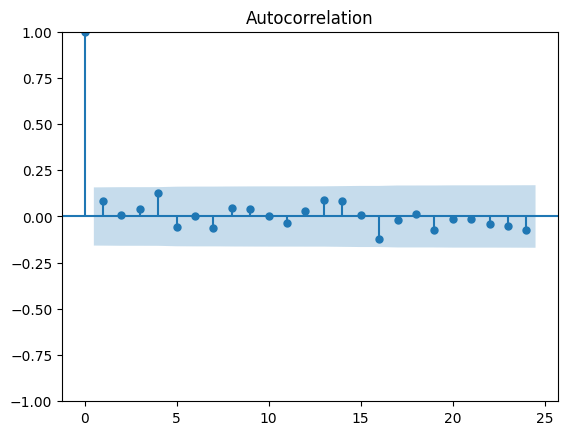

In [51]:
print(acf(transformed.price_log_diff.dropna(),nlags=24))
print('-'*50)
plot_acf(transformed.price_log_diff.dropna(),lags=24)
plt.show()

[ 1.          0.08537434  0.0032863   0.03820218  0.12327129 -0.08220904
  0.0101646  -0.07897476  0.05217743  0.05178058 -0.01029353 -0.01962378
  0.00807969  0.09390853  0.08170639  0.0056917  -0.16029901 -0.02993799
  0.00868066 -0.05723807  0.05210538 -0.03793468 -0.05981817 -0.06585647
 -0.07947248]
--------------------------------------------------


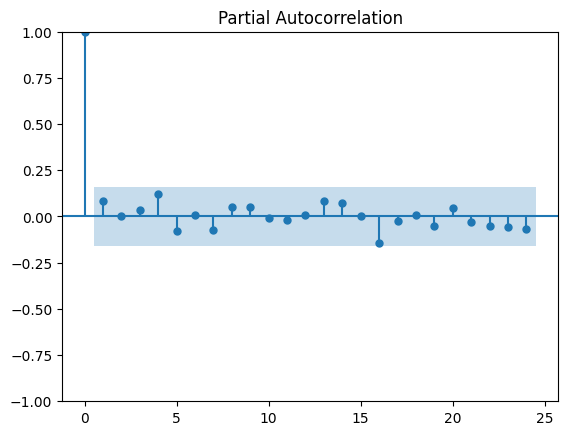

In [52]:
print(pacf(transformed.price_log_diff.dropna(), nlags = 24))
print('-'*50)
plot_pacf(transformed.price_log_diff.dropna(), lags=24)
plt.show()

[ 1.00000000e+00  8.48235405e-02  1.04149817e-02  3.83449123e-02
  1.25453869e-01 -5.71916472e-02  2.37493969e-04 -6.49277704e-02
  4.64484748e-02  3.84596545e-02  1.30872897e-04 -3.33416885e-02
  2.75137252e-02  8.84819254e-02  8.28589555e-02  8.74522329e-03
 -1.22386212e-01 -1.72124111e-02  1.25608797e-02 -7.28204310e-02
 -1.50777821e-02 -1.22891495e-02 -3.82970551e-02 -5.39241089e-02
 -7.56323041e-02]
--------------------------------------------------


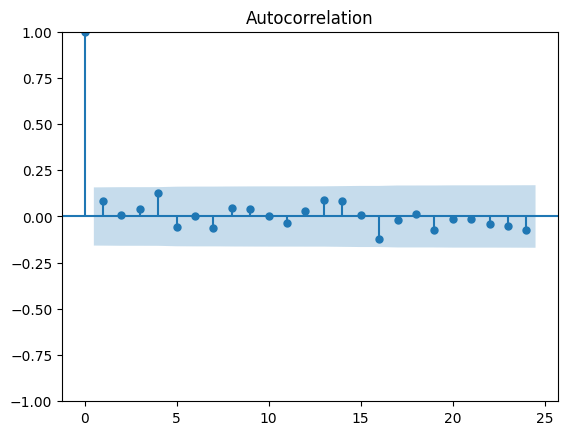

In [53]:
print(acf(transformed.price_log_diff.dropna(),nlags=24))
print('-'*50)
plot_acf(transformed.price_log_diff.dropna(),lags=24)
plt.show()

In [54]:
sarima_model = SARIMAX(train.log_price, order=(1,1,1), seasonal_order = (0,0,0,12))
result = sarima_model.fit()
result.aic

np.float64(-198.43671306125174)

lb_stat      7.452333
lb_pvalue    0.826333
Name: 12, dtype: float64


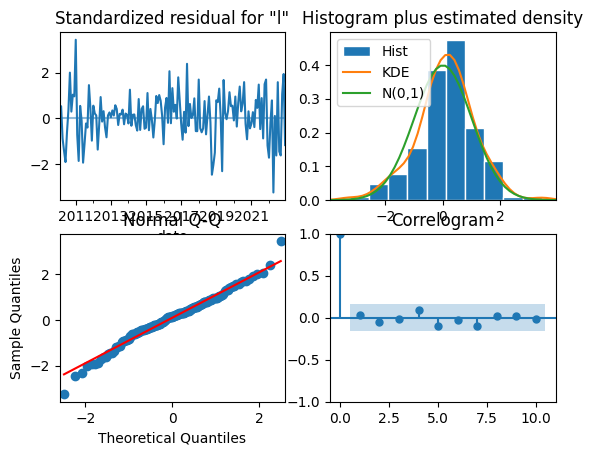

In [55]:
print(acorr_ljungbox(result.resid, lags = 12).iloc[11,:])
result.plot_diagnostics()
plt.show()

In [56]:
forecast_nvda = test.copy()
forecast_nvda['sarima1'] = np.exp(result.get_prediction(start = test.index[0], end = test.index[-1]).predicted_mean)

In [57]:
root_mean_squared_error(test.price, forecast_nvda.sarima1)

72.6710667793582

In [59]:
sarima_model = SARIMAX(train.log_price, order=(0,1,0), seasonal_order = (0,0,0,12))
result = sarima_model.fit()
result.bic

np.float64(-194.8552694209935)

lb_stat      8.091046
lb_pvalue    0.777976
Name: 12, dtype: float64


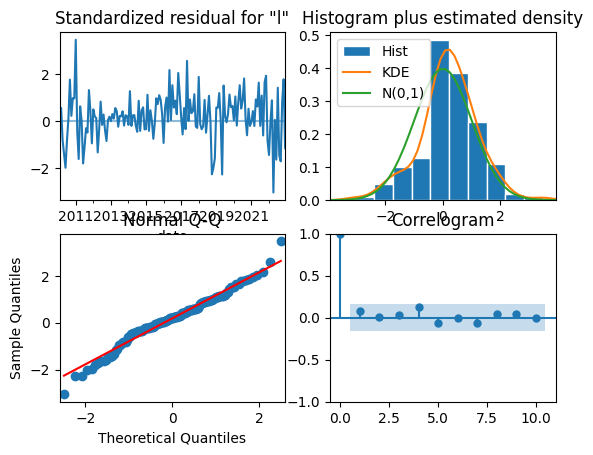

In [60]:
print(acorr_ljungbox(result.resid, lags = 12).iloc[11,:])
result.plot_diagnostics()
plt.show()

In [61]:
forecast_nvda['sarima2'] = np.exp(result.get_prediction(start = test.index[0], end = test.index[-1]).predicted_mean)

In [62]:
root_mean_squared_error(test.price, forecast_nvda.sarima2)

71.60848808078896

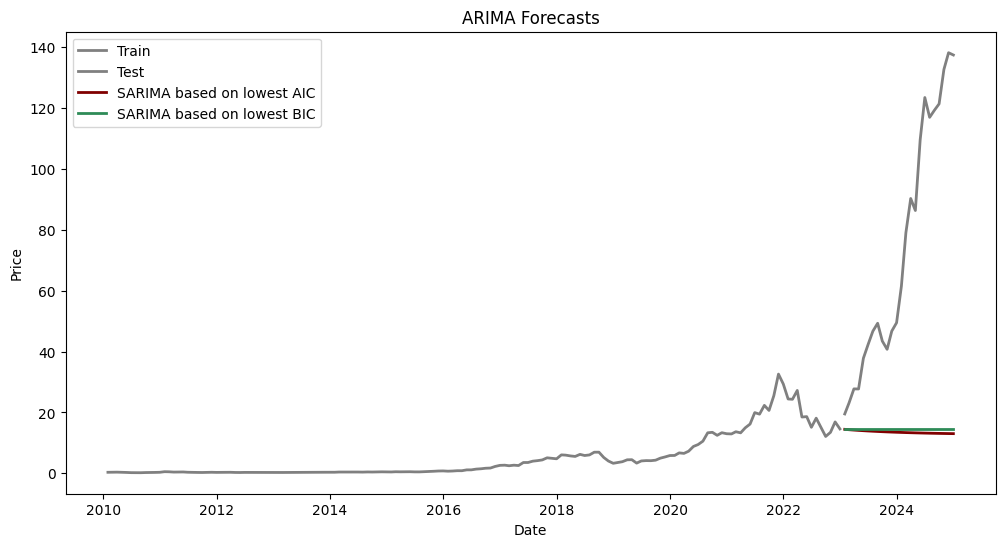

In [63]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train.price, label='Train', color = 'gray', lw = 2)
plt.plot(test.index, test.price, label='Test', color='gray', lw = 2)

plt.plot(test.index, forecast_nvda.sarima1, label='SARIMA based on lowest AIC', color = 'maroon', lw = 2)
plt.plot(test.index, forecast_nvda.sarima2, label='SARIMA based on lowest BIC', color = 'seagreen', lw = 2)

plt.title("ARIMA Forecasts")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

Sarima

In [64]:
gdp = pd.read_csv('Datasets/gdp.csv', parse_dates=['DATE'], index_col = 'DATE').asfreq('QS')
train = gdp.loc[:'2015-10-01',:]
test = gdp.loc['2016-01-01':,:]

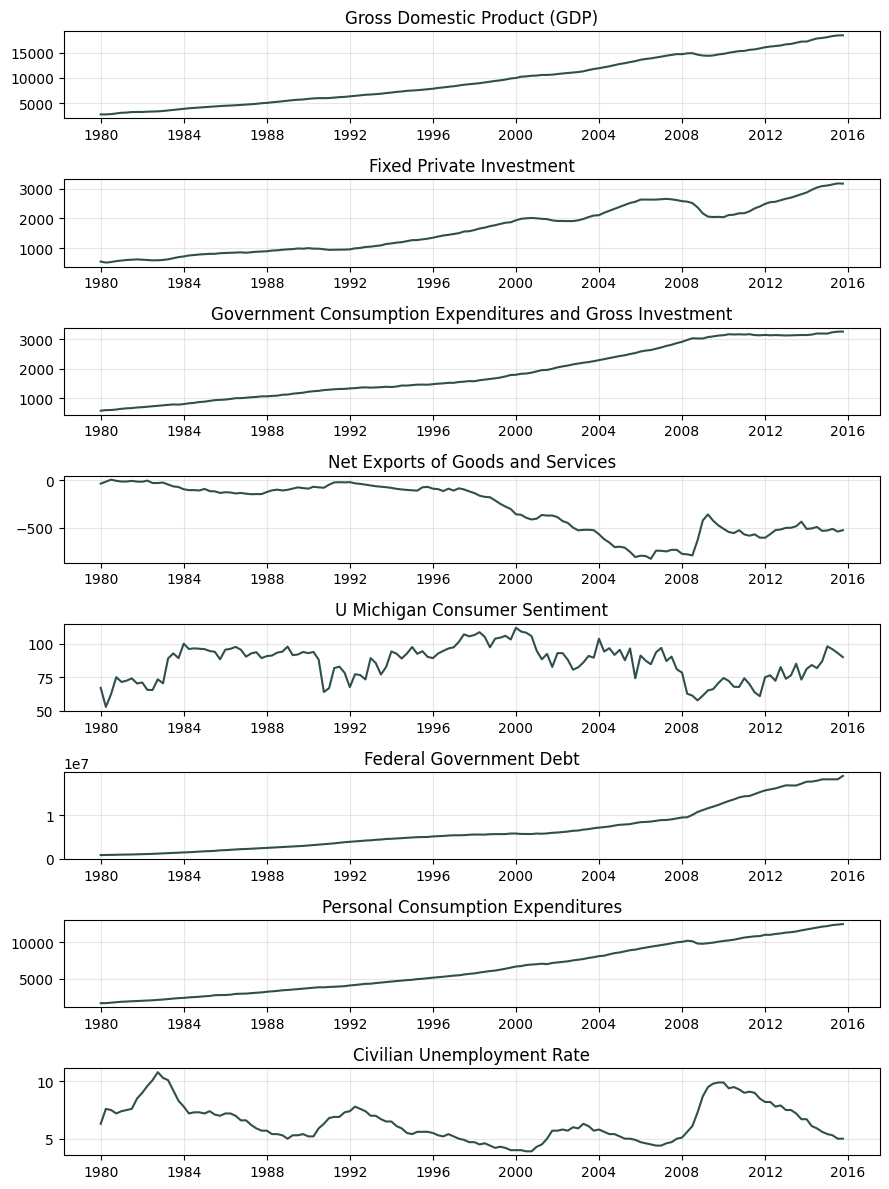

In [65]:
fig, ax = plt.subplots(8, 1, figsize= (9,12))


ax[0].plot(train.GDP, color = 'darkslategray')
ax[0].set_title('Gross Domestic Product (GDP)')
ax[0].grid(True, alpha=0.3)

ax[1].plot(train.FPI, color = 'darkslategray')
ax[1].set_title('Fixed Private Investment')
ax[1].grid(True, alpha=0.3)

ax[2].plot(train.GCE, color = 'darkslategray')
ax[2].set_title('Government Consumption Expenditures and Gross Investment')
ax[2].grid(True, alpha=0.3)

ax[3].plot(train.NETEXP, color = 'darkslategray')
ax[3].set_title('Net Exports of Goods and Services')
ax[3].grid(True, alpha=0.3)

ax[4].plot(train.UMCSENT, color = 'darkslategray')
ax[4].set_title('U Michigan Consumer Sentiment')
ax[4].grid(True, alpha=0.3)

ax[5].plot(train.GFDEBTN, color = 'darkslategray')
ax[5].set_title('Federal Government Debt')
ax[5].grid(True, alpha=0.3)

ax[6].plot(train.PCE, color = 'darkslategray')
ax[6].set_title('Personal Consumption Expenditures')
ax[6].grid(True, alpha=0.3)

ax[7].plot(train.UNRATE, color = 'darkslategray')
ax[7].set_title('Civilian Unemployment Rate')
ax[7].grid(True, alpha=0.3)
     
plt.tight_layout()
plt.show()

In [66]:
adfuller(train.GDP)[0], adfuller(train.GDP)[1]

(np.float64(1.982951747126811), np.float64(0.9986503850952133))

In [67]:
adfuller(train.GDP.diff().dropna())[0], adfuller(train.GDP.diff().dropna())[1]

(np.float64(-3.4489962101782767), np.float64(0.009397767306113141))

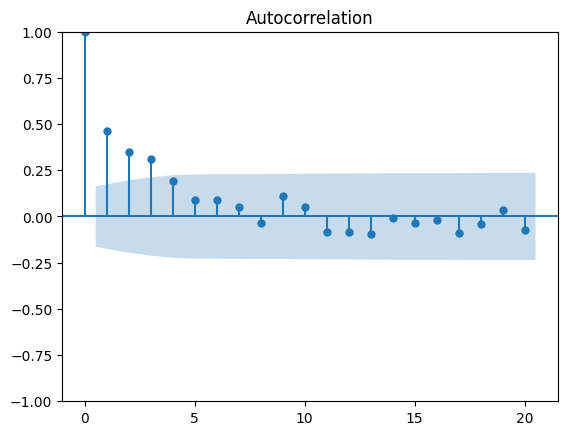

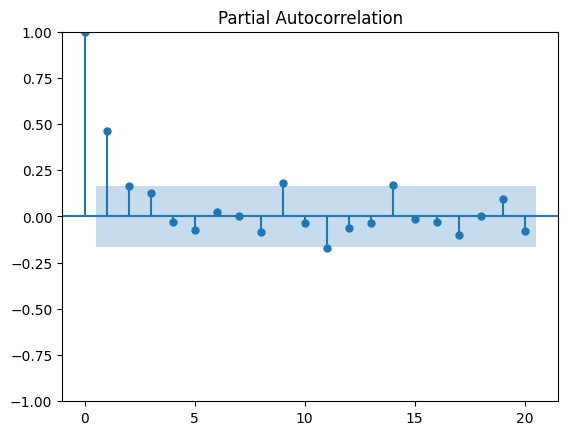

In [68]:
plot_acf(train.GDP.diff().dropna(), lags = 20)
plot_pacf(train.GDP.diff().dropna(), lags = 20)
plt.show()

In [69]:
model = SARIMAX(train.GDP, order = (1,1,1), seasonal_order=(1,1,1,4))
result = model.fit()
#result.summary()
print(result.aic)

1585.7533738646084


In [70]:
pred = result.get_prediction(start = test.index[0],end = test.index[-1]).predicted_mean
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(test.GDP, pred)

3545.3020675938396

In [71]:
exog = ['FPI', 'GCE', 'NETEXP', 'UMCSENT', 'GFDEBTN', 'PCE', 'UNRATE']
model = SARIMAX(train.GDP, order = (1,1,1), seasonal_order=(1,1,1,4), exog = train[exog])
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                               GDP   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 4)   Log Likelihood                -707.815
Date:                           Tue, 21 Apr 2026   AIC                           1439.630
Time:                                   11:25:21   BIC                           1474.844
Sample:                               01-01-1980   HQIC                          1453.940
                                    - 10-01-2015                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
FPI            1.3298      0.227      5.861      0.000       0.885       1.775
GCE            1.4791      0.398      3.712      0.000       0.698       2.260
NETEXP         0.4897      0.164      2.992      0.003       0.169       0.810
UMCSENT       -0.3613      0.910     -0.397      0.691      -2.145       1.423
GFDEBTN    -2.724e-05    5.2e-05     -0.523      0.601      -0.000    7.48e-05
PCE            0.3191      0.138      2.309      0.021       0.048       0.590
UNRATE       -41.2488     19.142     -2.155      0.031     -78.767      -3.731
ar.L1         -0.2268      0.604     -0.376      0.707      -1.410       0.956
ma.L1         -0.0273      0.620     -0.044      0.965      -1.243       1.188
ar.S.L4       -0.1188      0.234     -0.507      0.612      -0.578       0.340
ma.S.L4       -0.6559      0.232     -2.832      0.005      -1.110      -0.202
sigma2      2314.3458    463.092      4.998      0.000    1406.702    3221.989
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 4.24
Prob(Q):                              0.95   Prob(JB):                         0.12
Heteroskedasticity (H):               2.84   Skew:                            -0.17
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

lb_stat      16.973382
lb_pvalue     0.150601
Name: 12, dtype: float64


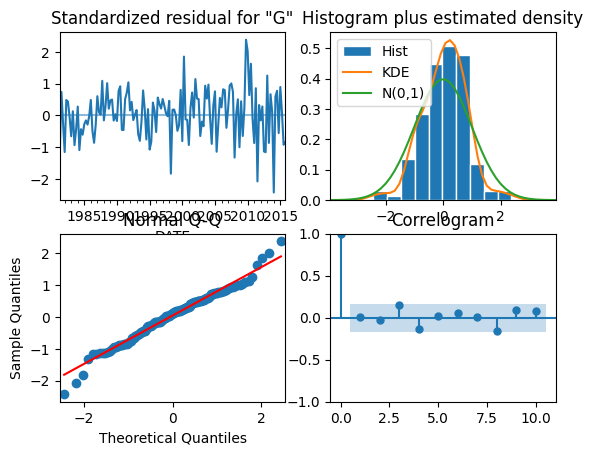

In [72]:
print(acorr_ljungbox(result.resid, lags = 12).iloc[11,:])
result.plot_diagnostics()
plt.show()

In [73]:
forecast = test.copy()
forecast['sarimax'] = result.get_prediction(start = test.index[0], end = test.index[-1], exog = test[exog]).predicted_mean
root_mean_squared_error(test.GDP, forecast.sarimax)


951.7488822334698

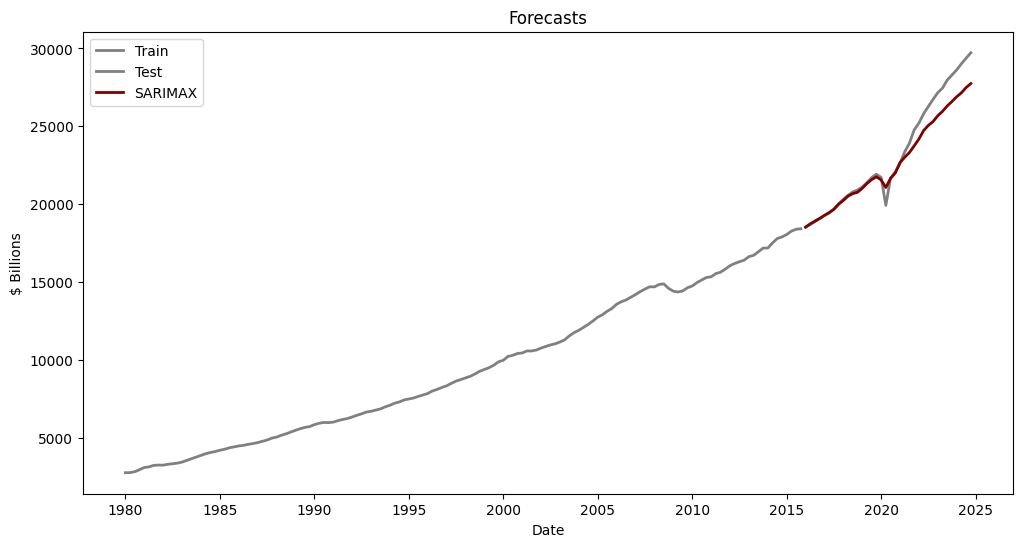

In [74]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train.GDP, label='Train', color = 'gray', lw = 2)
plt.plot(test.index, test.GDP, label='Test', color='gray', lw = 2)

plt.plot(test.index, forecast.sarimax, label='SARIMAX', color = 'maroon', lw = 2)

plt.title("Forecasts")
plt.xlabel("Date")
plt.ylabel("$ Billions")
plt.legend()
plt.show()